## Task 1 : Load and prepare data

Load the dog-cat-detection datasets. Resize the images in such a way that they have a fixed 112x112x3 format.


In [ ]:
#Datasets
from torchvision import datasets, transforms
from torch.utils.data import Dataset, Subset, DataLoader
import kagglehub
# Imports for network
import torch
import torch.nn as nn
import torch.nn.functional as F
#Imports for metrics caluclation/visualization
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
#Other imports
import numpy as np
from tqdm import tqdm

In [2]:
import os
import glob
import torch
import xml.etree.ElementTree as ET
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/dog-and-cat-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-detection' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-detection


Visualize cat-dog dataset

In [7]:
INPUT_IMG_SZ = 112      #resize to 112x112x3

IMG_DIR = os.path.join(path, "images")
ANNOTATION_DIR = os.path.join(path, "annotations")


class CatDogDataset(Dataset):
    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform
        self.img_files = sorted(glob.glob(os.path.join(img_dir, "*.png")))
        self.ann_files = sorted(glob.glob(os.path.join(ann_dir, "*.xml")))
        self.label_map = {"cat": 0, "dog": 1}  # Label mapping

    def parse_annotation(self, ann_path):
        tree = ET.parse(ann_path)
        root = tree.getroot()
        width = int(root.find("size/width").text)
        height = int(root.find("size/height").text)
        objects = []

        for obj in root.findall("object"):
            name = obj.find("name").text
            xmin = int(obj.find("bndbox/xmin").text)
            ymin = int(obj.find("bndbox/ymin").text)
            xmax = int(obj.find("bndbox/xmax").text)
            ymax = int(obj.find("bndbox/ymax").text)

            label = self.label_map.get(name, -1)  # Default to -1 if unknown label
            objects.append({"label": label, "bbox": [xmin, ymin, xmax, ymax]})

        return width, height, objects

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        ann_path = self.ann_files[idx]

        image = Image.open(img_path).convert("RGB")
        width, height, objects = self.parse_annotation(ann_path)

        scaler_x = width / INPUT_IMG_SZ
        scaler_y = height / INPUT_IMG_SZ

        bboxes = []
        for obj in objects:
            xmin = obj['bbox'][0] / scaler_x
            ymin = obj['bbox'][1] / scaler_y
            xmax = obj['bbox'][2] / scaler_x
            ymax = obj['bbox'][3] / scaler_y
            bboxes.append([xmin, ymin, xmax, ymax])  # in your assignment 4, you need to convert bbox into [x, y, w, h] and value range [0, 1]

        bboxes = torch.tensor(bboxes, dtype=torch.float32)
        labels = torch.tensor([obj["label"] for obj in objects], dtype=torch.int64)

        if self.transform:
            image = self.transform(image)

        return image, bboxes, labels


# Define transformations
transform = T.Compose([
    T.Resize((INPUT_IMG_SZ, INPUT_IMG_SZ)),
    T.ToTensor()
])

# Initialize dataset and dataloader
dataset = CatDogDataset(img_dir=IMG_DIR, ann_dir=ANNOTATION_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Function to visualize a batch
def visualize_batch(dataloader):
    images, bboxes, labels = next(iter(dataloader))
    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

    if len(images) == 1:
        axes = [axes]

    for i, (img, bbox, label) in enumerate(zip(images, bboxes, labels)):
        img = img.permute(1, 2, 0).numpy()
        axes[i].imshow(img)

        for box, lbl in zip(bbox, label):
            xmin, ymin, xmax, ymax = box.tolist()
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=2, edgecolor='r', facecolor='none')
            axes[i].add_patch(rect)
            axes[i].text(xmin, ymin - 5, f'Label: {lbl.item()}', color='red', fontsize=10,
                         bbox=dict(facecolor='white', alpha=0.5))
        axes[i].axis('off')

    plt.show()


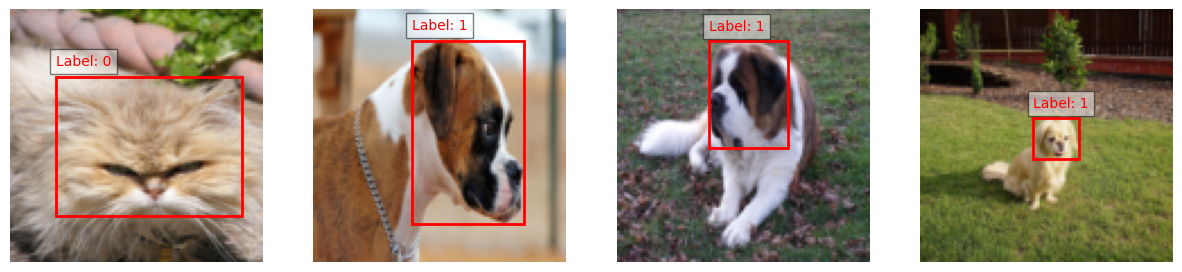

In [8]:
# Visualize a batch
visualize_batch(dataloader)

Split into test and training data

In [9]:
labels = []
for ann_path in dataset.ann_files:
    _, _, object = dataset.parse_annotation(ann_path)
    
    label = object[0]["label"]
    labels.append(label)

In [10]:
indices = list(range(len(dataset)))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [11]:
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

In [27]:
train_data = DataLoader(train_set, batch_size = 32, shuffle = True, pin_memory = True, collate_fn=lambda x: tuple(zip(*x)))
val_data = DataLoader(val_set, batch_size = 32, shuffle = False, pin_memory = True, collate_fn=lambda x: tuple(zip(*x)))

## Task 2 : Develop the architecture

<li> Your network contains the layers below. The output is similar to the YOLOv1 output, with a 7x7 spatial grid but with B=1 detections per cell, and only C=2 classes.</li>
<li>You can decide the type of pooling, activation functions, and whether or not to use dropout and batch normalization.</li>

Pay attention to the activation function of the output layer. At this point, we're not using non-maximum suppression. Your network should have approximately 1M parameters.

In [13]:
class ObjectDetector(nn.Module):
    #(N - F + 2*P) / S + 1
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, stride = 1, padding=1, padding_mode='zeros')
        #input size: 3x112x112 -> output size: 112 - 3 + 2 + 1 = 16 x 112 x 112
        self.batch1 = nn.BatchNorm2d(num_features = self.conv1.out_channels)
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0)
        #input size: 16 x 112 x 112 -> output size: 16 x 56 x 56
        
        self.conv2 = nn.Conv2d(in_channels = self.conv1.out_channels, out_channels = 32, kernel_size = 3, stride = 1, padding = 1, padding_mode = 'zeros')
        #input size: 16 x 56 x 56 -> output size: 32 x 56 x 56
        self.batch2 = nn.BatchNorm2d(num_features = self.conv2.out_channels)
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0)
        # input size: 32 x 56 x 56 -> output size: 32 x 28 x 28

        self.conv3 = nn.Conv2d(in_channels = self.conv2.out_channels, out_channels = 64, kernel_size = 3 ,stride = 1, padding = 1, padding_mode = 'zeros')
        #input size: 32 x 28 x 28 -> output size: 64 x 28 x 28
        self.batch3 = nn.BatchNorm2d(num_features = self.conv3.out_channels)
        self.pool3 = nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0)
        #input size: 64 x 28 x 28 -> output size: 64 x 14 x 14

        self.conv4 = nn.Conv2d(in_channels = self.conv3.out_channels, out_channels = 64, kernel_size = 3, stride = 1, padding = 1, padding_mode = 'zeros')
        #input size: 64 x 28 x 28 -> output size: 64 x 28 x 28
        self.batch4 = nn.BatchNorm2d(num_features = self.conv4.out_channels)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride = 2, padding = 0)
        #input size: 64 x 14 x 14 -> output size: 64 x 7 x 7

        self.conv5 = nn.Conv2d(in_channels = self.conv4.out_channels, out_channels = 32, kernel_size = 3, stride = 1, padding = 1, padding_mode = 'zeros')
        #input size: 64 x 7 x 7 -> output size: 32 x 7 x 7
        self.batch5 = nn.BatchNorm2d(num_features = self.conv5.out_channels)
        
        self.flatten = nn.Flatten()

        self.drop = nn.Dropout(p = 0.5)
        self.full = nn.Linear(in_features = 32*7*7, out_features = 512)
        self.out = nn.Linear(in_features = self.full.out_features, out_features = 343)

    def forward(self, x):
        x = self.conv1(x)
        x = self.batch1(x)
        x = F.relu(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.batch2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.batch3(x)        
        x = F.relu(x)
        x = self.pool3(x)
        
        x = self.conv4(x)
        x = self.batch4(x)
        x = F.relu(x)
        x = self.pool4(x)

        x = self.conv5(x)

        x = self.batch5(x)
        x = F.relu(x)
        x = self.flatten(x)
        x = self.drop(x)
        x = self.full(x)
        x = F.relu(x)
        x = self.out(x)
        x = torch.sigmoid(x)

        return x

In [14]:
model = ObjectDetector()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 1058679


In [23]:
class YOLOLoss(nn.Module):
    def __init__(self, batch_size = 32, grid_size = 7):
        super().__init__()
        self.batch = batch_size
        self.grid = grid_size

    def forward(self, pred, target, weight_coord = 5, weight_size = 5, weight_conf_yes = 1, weight_conf_no = 0.5, weight_class = 1):
        # Convert the flattened tensor from 343 to 7 x 7 x 7
        pred = torch.reshape(pred, (-1, self.grid, self.grid, 7))
        target = torch.reshape(target, (-1, self.grid, self.grid, 7))

        #Create a mask to detect where the object is by looking at the confidence (index 4)
        #Store both the mask if there is the object or if there is not
        mask_yes = target[:, :, :, 4] == 1
        mask_no = ~mask_yes

        #Create the yololoss with 5 terms. take difference x_c and y_c
        pred_center = pred[mask_yes, 0:2]
        target_center = target[mask_yes, 0:2]
        coordinate_loss = torch.nn.functional.mse_loss(pred_center, target_center)

        # size loss
        # we use clamp because torch.sqrt could produce nan if predictions are negativre
        pred_wh = torch.sqrt(torch.clamp(pred[mask_yes, 2:4], min=1e-6))
        target_wh = torch.sqrt(torch.clamp(target[mask_yes, 2:4], min=1e-6))
        size_loss = torch.nn.functional.mse_loss(pred_wh, target_wh)

        #confidence loss for cells where there is the target
        pred_conf_yes = pred[mask_yes, 4]
        target_conf_yes = target[mask_yes, 4]
        confidence_loss_yes = torch.nn.functional.mse_loss(pred_conf_yes, target_conf_yes)

        #confidence loss for cells whete there is no target
        pred_conf_no = pred[mask_no, 4]
        target_conf_no = target[mask_no, 4]
        confidence_loss_no = torch.nn.functional.mse_loss(pred_conf_no, target_conf_no)

        #loss for the correct class prediction
        pred_class = pred[mask_yes, 5:7]
        target_class = target[mask_yes, 5:7]
        class_loss = torch.nn.functional.mse_loss(pred_class, target_class)

        total_loss = weight_coord * coordinate_loss
        total_loss += weight_size * size_loss
        total_loss += weight_conf_yes * confidence_loss_yes
        total_loss += weight_conf_no * confidence_loss_no
        total_loss += weight_class * class_loss

        return total_loss

In [48]:
class TrainDetector(nn.Module):
    def __init__(self, model, optimizer, loss, device, data_loader, val_loader):
        super().__init__()
        self.model = model
        self.opt = optimizer
        self.loss = loss
        self.device = device
        self.data = data_loader
        self.val = val_loader
    
    def _change_bbox(self, bbox, labels, grid_size = 7, im_size = 112):
        """
            Function to change the format of the bounding boxes from [xmin, ymin, xmax, ymax]
            to [xcenter, ycenter, width, height, confidence, one hot encoding].
            param: bbox (list): list containing the bbox coordinates in the format [xmin, ymin, xmax, ymax]
            param: labels (list): list of the labels for each bbox
            param: grid_size (int): size of the grid in which to divide the image
            param: im_size (int): size of the image
            returns: new_bbox (list): flattened version of the tensor
        """
        new_bbox = torch.zeros(grid_size, grid_size, 7, device = self.device)
        # Find the new values for the bbox expressed as the centre of the bbox
        # and the width and height, along with confidence and class
        for box, label in zip(bbox, labels):
            x_c = (box[0] + box[2]) / 2 
            y_c = (box[1] + box[3]) / 2 
            norm_xc = x_c / im_size
            norm_yc = y_c / im_size
            w = (box[2] - box[0]) / (im_size)
            h = (box[3] - box[1]) / (im_size)
            # We find where in the grid the object actually is
            # by multiplying the normalized centre coordinates by the grid size
            # Since this represents a fraction of the grid. We take the int
            col = min(int(norm_xc * grid_size), grid_size - 1)
            row = min(int(norm_yc * grid_size), grid_size - 1)

            #The cell with the image has 7 values
            new_bbox[row, col, 0] = (norm_xc * grid_size) - col
            new_bbox[row, col, 1] = (norm_yc * grid_size) - row
            new_bbox[row, col, 2] = w
            new_bbox[row, col, 3] = h
            new_bbox[row, col, 4] = 1 # confidence
            if label == 0:
                new_bbox[row, col, 5] = 1
                new_bbox[row, col, 6] = 0
            elif label == 1:
                new_bbox[row, col, 5] = 0
                new_bbox[row, col, 6] = 1
        return new_bbox.flatten()

    def _forward_pass(self, data, bboxes, labels):
        data = torch.stack(data).to(self.device)
        target = torch.stack([
            self._change_bbox(bbox, label)
            for bbox, label in zip(bboxes, labels)
        ]).to(self.device)

        pred = self.model(data)
        loss = self.loss(pred, target)
        return loss

    def validate(self):
        self.model.eval()
        val_losses = []
        with torch.no_grad():
            for (data, bbox, label) in self.val:
                val_loss = self._forward_pass(data, bbox, label)
                val_losses.append(val_loss.item())
        self.model.train()
        return np.mean(val_losses)

    def train(self, epochs, epsilon = 1e-4, verbose = False):
        #For each epoch
        val_losses = []
        for epoch in range(epochs):
            if verbose:
                print(f"Started training on epoch {epoch}")
            self.model.train()
            losses = []
            #For each batch
            for i, (data, bbox, label) in enumerate(tqdm(self.data, f"Training epoch {epoch + 1}")): 
                self.opt.zero_grad()
                loss = self._forward_pass(data, bbox, label)
                loss.backward()
                self.opt.step()
                losses.append(loss.item())
                if verbose:
                    print(f"Loss for batch {i + 1} in epoch {epoch}: {loss}")
            
            val_loss = self.validate()
            if verbose:
                print(f"Validation loss in epoch {epoch}: {val_loss}")
            val_losses.append(val_loss)

            if len(val_losses) > 1 and abs(val_losses[-1] - val_losses[-2]) < epsilon:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

            avg_loss = np.mean(losses)
            avg_val_loss = np.mean(val_losses)
            if verbose:
                print(f"Average training loss across epochs: {avg_loss}")
                print(f"Average validation loss across epochs: {avg_val_loss}")

        return avg_loss, avg_val_loss

    def evaluate(self, threshold = 0.5, grid_size = 7, conf_matrix = False):
        self.model.eval()
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for (data, bboxes, labels) in self.val:
                data = torch.stack(data).to(self.device)
                pred = self.model(data)
                pred = pred.reshape(-1, grid_size, grid_size, 7)

                target = torch.stack([self._change_bbox(bbox, label) 
                      for bbox, label in zip(bboxes, labels)])
                target = target.reshape(-1, 7, 7, 7)
                
                mask = pred[: ,: ,:, 4] > threshold
                pred_class = torch.argmax(pred[:,:,:,5:7], dim = -1)
                true_class = torch.argmax(target[:,:,:,5:7], dim = -1)

                all_preds.extend(pred_class[mask].cpu().numpy())
                all_targets.extend(true_class[mask].cpu().numpy())
        
        if conf_matrix:
            cm = confusion_matrix(all_targets, all_preds)
            sns.heatmap(cm, annot = True, fmt = 'd')
            plt.show()

        accuracy = accuracy_score(all_targets, all_preds)
        return accuracy

    def test(self, test_loader):
        self.model.eval()
        test_losses = []
        results = []
        with torch.no_grad():
            for (data, bbox, label) in test_loader:
                test_loss = self._forward_pass(data, bbox, label)
                test_losses.append(test_loss.item())
        thresholds = np.linspace(0,1,20)
        for t in thresholds:
            accuracy = self.evaluate(threshold = t)
            results.append((t, accuracy))
        
        return np.mean(test_losses)

## Task 3 : Train your object detector model

<li>Use the dog-cat-detection train and val sets to train your network from scratch.</li>
<li>use early stopping on the loss of your val set. </li>
<li>Use the same five losses as in the original YOLOv1 paper, with the same weights. </li>
<li>You are free to choose your hyperparameters, including batch size, optimizer and learning rate.</li>

In [45]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ObjectDetector().to(device)
epochs = 5
loss_function = YOLOLoss()
learning_rate = 1e-4
optimizer = torch.optim.Adam(params = model.parameters(), lr = learning_rate)

In [51]:
trainer = TrainDetector(model, optimizer, loss_function, device, train_data, val_data)
avg_loss, avg_val_loss = trainer.train(epochs)

Training epoch 5: 100%|██████████| 93/93 [00:27<00:00,  3.37it/s]


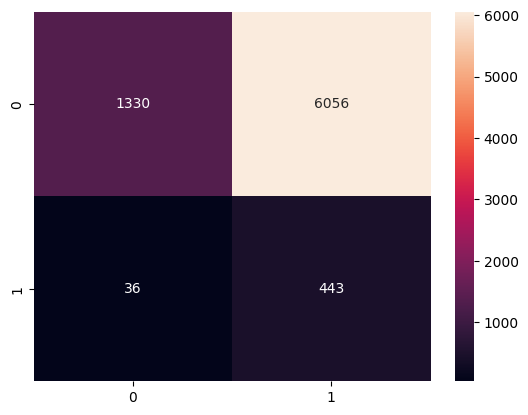

Validation Accuracy: 22.54%


In [52]:
accuracy = trainer.evaluate(threshold=0.5, conf_matrix=True)

print(f"Validation Accuracy: {accuracy * 100:.2f}%")

## Task 4 : Evaluate the performance of your trained model

<li>Report the mAP when changing the objectness threshold from 0 to 1.</li>
<li>Present a confusion matrix for the threshold setting for which mAP is maximal.</li>

In [ ]:
def plot_results(trainer, dataloader, num_images=4):
    trainer.model.eval()
    images, bboxes, labels = next(iter(dataloader))
    
    # Move data to device and stack
    img_tensor = torch.stack(images).to(trainer.device)
    
    with torch.no_grad():
        predictions = trainer.model(img_tensor).reshape(-1, 7, 7, 7)

    fig, axes = plt.subplots(1, num_images, figsize=(20, 5))
    for i in range(num_images):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(img)
        
        # Look through the 7x7 grid for high confidence
        for row in range(7):
            for col in range(7):
                conf = predictions[i, row, col, 4].item()
                if conf > 0.5:  # Threshold
                    # Convert local offsets back to 112x112 pixels
                    # (Col + offset) * (ImgSize / GridSize)
                    cx = (col + predictions[i, row, col, 0].item()) * (112 / 7)
                    cy = (row + predictions[i, row, col, 1].item()) * (112 / 7)
                    w = predictions[i, row, col, 2].item() * 112
                    h = predictions[i, row, col, 3].item() * 112
                    
                    # Calculate top-left for the rectangle
                    rect = patches.Rectangle((cx - w/2, cy - h/2), w, h, 
                                           linewidth=2, edgecolor='g', facecolor='none')
                    axes[i].add_patch(rect)
                    
                    label = "Dog" if predictions[i, row, col, 6] > predictions[i, row, col, 5] else "Cat"
                    axes[i].text(cx - w/2, cy - h/2 - 5, f'{label} {conf:.2f}', 
                                color='lime', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))
        axes[i].axis('off')
    plt.show()

# Call this to see the "cats and dogs"
plot_results(trainer, val_data)